In [2]:
from google.colab import drive

print("Connecting to Google Drive...")
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

print("Loading the FULL dataset from Google Drive...")

file_path = '/content/drive/MyDrive/Retail_AI_Data/OnlineRetail.csv'

df_full = pd.read_csv(file_path, encoding='unicode_escape')

print("Data load successfully 🎉\n")
print(f"Data set shape: {df_full.shape}")

display(df_full.head())


Loading the FULL dataset from Google Drive...
Data load successfully 🎉

Data set shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
import datetime as dt

print("1. Data Cleaning (ලක්ෂ 5ම පිරිසිදු කිරීම)...")
# CustomerID නැති ඒවා අයින් කිරීම
df_clean = df_full.dropna(subset=['CustomerID', 'Description'])

# ආපසු දුන් බඩු (සෘණ අගයන්) අයින් කිරීම
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)].copy()

# TotalSpend ගණනය කිරීම
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("2. RFM Matrix හැදීම...")
# දිනයන් Pandas format එකට හැරවීම (මේකට තත්පර කිහිපයක් යයි)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
latest_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by කරලා RFM අගයන් ගණනය කිරීම
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum'
})

# Columns වල නම් වෙනස් කිරීම
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
}, inplace=True)

print("වැඩේ ඉවරයි! 🚀\n")
print(f"අවසාන පාරිභෝගිකයින් (Unique Customers) ගණන: {rfm.shape[0]}\n")
display(rfm.head())

1. Data Cleaning (ලක්ෂ 5ම පිරිසිදු කිරීම)...
2. RFM Matrix හැදීම...
වැඩේ ඉවරයි! 🚀

අවසාන පාරිභෝගිකයින් (Unique Customers) ගණන: 4338



,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


1. Scaling the Full Data...
2. Calculating Elbow Curve for 4338 customers...


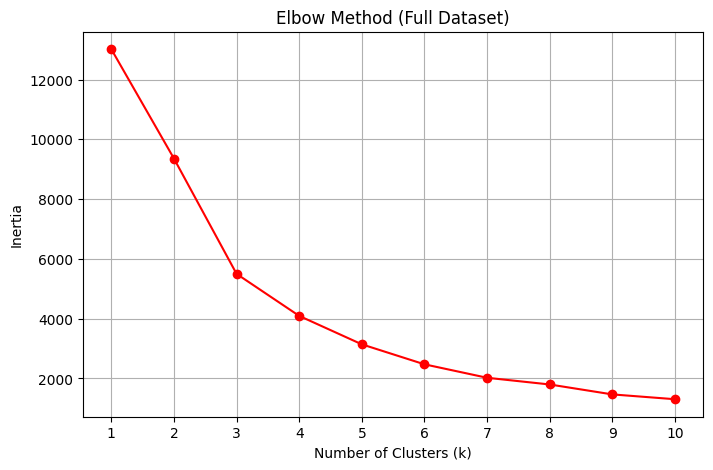

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("1. Scaling the Full Data...")
# දත්ත සමබර කිරීම
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

print("2. Calculating Elbow Curve for 4338 customers...")
inertias = []
ks = range(1, 11)

# කණ්ඩායම් 1 ඉඳන් 10 වෙනකම් පරීක්ෂා කිරීම
for k in ks:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertias.append(model.inertia_)

# ප්‍රස්ථාරය ඇඳීම
plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, '-o', color='red') # මේ පාර රතු පාටින් අඳිමු!
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method (Full Dataset)')
plt.xticks(ks)
plt.grid(True)
plt.show()

In [6]:
print("Grouping all 4338 customers into 3 clusters...")

# 1. K-Means model එක Cluster 3 කින් හැදීම
kmeans = KMeans(n_clusters=3, random_state=42)

# 2. Scale කරපු දත්ත දීලා කණ්ඩායම් හොයාගැනීම
cluster_labels = kmeans.fit_predict(rfm_scaled)

# 3. කණ්ඩායම් අංකය RFM වගුවට එකතු කිරීම
rfm['Cluster'] = cluster_labels

print("\n--- කණ්ඩායම් 3ට පාරිභෝගිකයින් බෙදී ඇති ආකාරය ---")
print(rfm['Cluster'].value_counts().sort_index())

# 4. කණ්ඩායම් වල සාමාන්‍ය හැසිරීම (Profile) බැලීම
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

print("\n--- කණ්ඩායම් වල සාමාන්‍ය හැසිරීම (Cluster Averages) ---")
display(cluster_profile)

Grouping all 4338 customers into 3 clusters...

--- කණ්ඩායම් 3ට පාරිභෝගිකයින් බෙදී ඇති ආකාරය ---
Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64

--- කණ්ඩායම් වල සාමාන්‍ය හැසිරීම (Cluster Averages) ---


Recency Frequency  Monetary      
           mean      mean      mean count
Cluster                                  
0          41.0       4.9    2012.1  3231
1         246.0       1.6     631.1  1093
2           7.1      80.2  122888.4    14

In [7]:
print("Creating the Full User-Item Matrix...")
# මේකට තත්පර 10-20 ක් යන්න පුළුවන් (ලොකු දත්ත ප්‍රමාණයක් නිසා)

user_item_matrix = df_clean.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print("Matrix හැදුවා! 🎉")
print(f"Matrix Shape: {user_item_matrix.shape}")

Creating the Full User-Item Matrix...
Matrix හැදුවා! 🎉
Matrix Shape: (4338, 3877)


In [8]:
from sklearn.decomposition import NMF

print("Training NMF Model on Full Dataset (This might take a few seconds)...")

# 1. NMF model එක හැදීම (ප්‍රධාන භාණ්ඩ රටාවන් 20 ක් හොයමු)
nmf_model = NMF(n_components=20, random_state=42)

# 2. Model එකට දත්ත දීලා train කිරීම (fit_transform)
nmf_features = nmf_model.fit_transform(user_item_matrix)

print("NMF Training සාර්ථකයි! 🎉")
print(f"පාරිභෝගිකයින්ගේ අලුත් Matrix හැඩය (Customers, Features): {nmf_features.shape}")

Training NMF Model on Full Dataset (This might take a few seconds)...
NMF Training සාර්ථකයි! 🎉
පාරිභෝගිකයින්ගේ අලුත් Matrix හැඩය (Customers, Features): (4338, 20)


In [9]:
from sklearn.preprocessing import normalize

print("Final Step: Big Data Recommender Engine in Action! 🚀\n")

# 1. NMF features ටික normalize කිරීම (Cosine Similarity වලට ලේසි වෙන්න)
norm_features = normalize(nmf_features)
df_features = pd.DataFrame(norm_features, index=user_item_matrix.index)

# 2. Recommender Function එක (කලින් අපි හදපු එකමයි)
def recommend_items(target_customer_id, user_matrix, feature_matrix, top_n=3):
    try:
        similarities = feature_matrix.dot(feature_matrix.loc[target_customer_id])
        similar_customers = similarities[similarities < 0.99].sort_values(ascending=False)
        best_match_id = similar_customers.index[0]
        match_score = similar_customers.iloc[0]

        print(f"[{target_customer_id}] ට වඩාත්ම සමාන පාරිභෝගිකයා: {best_match_id} (සමානතා අගය: {match_score:.4f})")

        best_match_items = user_matrix.loc[best_match_id]
        best_match_bought = best_match_items[best_match_items > 0].index.tolist()

        target_customer_items = user_matrix.loc[target_customer_id]
        target_customer_bought = target_customer_items[target_customer_items > 0].index.tolist()

        recommendations = [item for item in best_match_bought if item not in target_customer_bought]

        print(f"\nඔබ මේ භාණ්ඩ වලටත් කැමති විය හැකියි (Top {top_n} Recommendations):")
        if not recommendations:
            print("  -> කණගාටුයි, අලුත් නිර්දේශ කිසිවක් හමු නොවීය.")
        else:
            for i, item in enumerate(recommendations[:top_n], 1):
                print(f"  {i}. {item}")

    except KeyError:
        print("මෙම පාරිභෝගිකයා දත්ත ගොනුවේ නොමැත!")

# 3. අපේ දත්ත සෙට් එකේ ඉන්න පළවෙනි පාරිභෝගිකයාව (Customer 0) අරගෙන ටෙස්ට් කරමු
test_customer = df_features.index[0]
recommend_items(test_customer, user_item_matrix, df_features)

Final Step: Big Data Recommender Engine in Action! 🚀

[12346.0] ට වඩාත්ම සමාන පාරිභෝගිකයා: 17309.0 (සමානතා අගය: 0.9046)

ඔබ මේ භාණ්ඩ වලටත් කැමති විය හැකියි (Top 3 Recommendations):
  1. CLASSIC GLASS COOKIE JAR
  2. GAOLERS KEYS DECORATIVE GARDEN 
  3. LARGE CAKE TOWEL PINK SPOTS


In [10]:
recommend_items(17309.0, user_item_matrix, df_features)

[17309.0] ට වඩාත්ම සමාන පාරිභෝගිකයා: 17030.0 (සමානතා අගය: 0.9880)

ඔබ මේ භාණ්ඩ වලටත් කැමති විය හැකියි (Top 3 Recommendations):
  1. 50'S CHRISTMAS PAPER GIFT BAG
  2. BLUE POLKADOT CUP
  3. CUSHION COVER PINK UNION JACK


In [11]:
test_customer = df_features.index[10]
recommend_items(test_customer, user_item_matrix, df_features)

[12357.0] ට වඩාත්ම සමාන පාරිභෝගිකයා: 17052.0 (සමානතා අගය: 0.9674)

ඔබ මේ භාණ්ඩ වලටත් කැමති විය හැකියි (Top 3 Recommendations):
  1.  DOLLY GIRL BEAKER
  2. 12 PENCILS TALL TUBE RED RETROSPOT
  3. 12 PENCILS TALL TUBE WOODLAND
